# Interbank Challengue - Data Science

**Contexto del Desafío**

Un banco líder ha identificado un incremento en problemas dentro de su cartera de préstamos. Durante los últimos 3 años se ha recopilado información histórica de otorgación
crediticia.  
El objetivo es transformar el proceso tradicional mediante un sistema de pre-evaluación automatizado basado en Machine Learning.

**El Reto**

Diseñar un modelo predictivo que estime la probabilidad de que un cliente experimente dificultades financieras en los próximos 24 meses. El modelo deberá mejorar la predicción del riesgo y apoyar decisiones estratégicas.

**Objetivos Clave**

- Construcción de variables de comportamiento histórico (preprocesamiento).
- Manejo de desbalance de datos
- Validación temporal del modelo.
- Definición de cutoff óptimo.
- Evaluación con métricas: AUC, GINI y Recall del modelo.
- Diseño del Testing A/B
- Definir el flujo de implementación en el canal de digital (mailing).

**Impacto Esperado**

- Mejor control del riesgo crediticio.
- Disminución de deterioro de cartera.
- Toma de decisiones basada en datos.
- Mayor eficiencia en la aprobación de préstamos

# Import libraries

In [1]:
import re
import math
import pandas as pd
import numpy as np
import json
from pandas import json_normalize
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve
)
from lightgbm import LGBMClassifier

# Lectura de fuentes

## Diccionario de Datos – Modelo de Riesgo Crediticio

| Nombre variable | Descripción | Tipo |
|-----------------|------------|------|
| **Default** | Cliente con más de 90 días sin pagar su préstamo | Y/N |
| **Prct_uso_tc** | Porcentaje del uso de tarjeta de crédito el último mes | Percentage |
| **Edad** | Edad del cliente | Integer |
| **Nro_prestao_retrasados** | Número de préstamos con retraso en el pago de más de 3 meses en los últimos 3 años | Integer |
| **Prct_deuda_vs_ingresos** | Ratio de deuda financiera vs ingresos del cliente | Percentage |
| **Mto_ingreso_mensual** | Monto de ingreso mensual | Real |
| **Nro_prod_financieros_deuda** | Número de préstamos (incluye créditos vehiculares o hipotecarios) y número de tarjetas de crédito último año | Integer |
| **Nro_retraso_60dias** | Número de veces que el cliente se ha retrasado más de 60 días en los últimos 3 años | Integer |
| **Nro_creditos_hipotecarios** | Número de créditos hipotecarios | Integer |
| **Nro_retraso_ultm3anios** | Número de retrasos en pagos de más de 30 días en los últimos 3 años | Integer |
| **Nro_dependiente** | Número de dependientes | Integer |

---

## Variable Objetivo

**Default**  
- Y (1) = Cliente con más de 90 días de mora  
- N (0)= Cliente sin mora significativa  

Tipo de problema: **Clasificación Binaria (Riesgo Crediticio)**

In [2]:
# Leer dataset
credit_data = pd.read_csv("Dataset/Dataset.csv")
# Ver primeras filas
credit_data.head()

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
print(credit_data.shape)
credit_data.info()
credit_data["Default"].value_counts(normalize=True)

(150000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          150000 non-null  int64  
 1   Default                     150000 non-null  int64  
 2   Prct_uso_tc                 150000 non-null  float64
 3   Edad                        150000 non-null  int64  
 4   Nro_prestao_retrasados      150000 non-null  int64  
 5   Prct_deuda_vs_ingresos      150000 non-null  float64
 6   Mto_ingreso_mensual         120269 non-null  float64
 7   Nro_prod_financieros_deuda  150000 non-null  int64  
 8   Nro_retraso_60dias          150000 non-null  int64  
 9   Nro_creditos_hipotecarios   150000 non-null  int64  
 10  Nro_retraso_ultm3anios      150000 non-null  int64  
 11  Nro_dependiente             146076 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 13.7 MB


Default
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [4]:
credit_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
Default,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
Prct_uso_tc,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
Edad,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
Nro_prestao_retrasados,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
Prct_deuda_vs_ingresos,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
Mto_ingreso_mensual,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
Nro_prod_financieros_deuda,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
Nro_retraso_60dias,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
Nro_creditos_hipotecarios,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


**Insights**:

- Dataset desbalanceado (minoría positiva): ~6.7% de casos default.
    Esto implica:
    - No usar accuracy.
    - Usar ROC-AUC.
    - Considerar class_weight o ajuste de threshold.
- Variables Percentage mal escaladas:
    - ``Prct_uso_tc``: Mean = 6.04, Max = 50708
    - ``Prct_deuda_vs_ingresos``: Mean = 353, Max = 329664
    - No son porcentajes normales, implica revisión y posible tratamiento.
- Ingresos con valores extremos (``Mto_ingreso_mensual``)
    - Mean = 6670, Max = 3008750
    - Requiere tratamiento (Log transform, Winsorization, Outlier capping)
- Missing values:
    - ``Mto_ingreso_mensual``: 120269. Hay ~30k faltantes
    - ``Nro_dependiente``: 146076. Hay ~4k faltantes
    - Ver posibilidad de imputación
- Variables de mora (``Nro_retraso_60dias``, ``Nro_retraso_ultm3anios``, ``Nro_prestao_retrasados``):
    - Todas tienen: Mediana = 0, 75% = 0
    - Muy sesgadas hacia cero.
    - Son variables típicas de riesgo crediticio, probablemente serán las más predictivas.


# 1. Preprocesamiento de datos

## 1.1 Copia de seguridad

Nunca trabajamos sobre el raw directamente:

In [5]:
credit_df = credit_data.copy()
credit_df.head()

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 1.2 Eliminación de variables no predictivas

``ID`` no debe entrar al modelo. Evita overfitting artificial y leakage indirecto.

In [6]:
credit_df.drop(columns=["ID"], inplace=True)

## 1.3 Validación del Target

Ya validado que Default está en formato binario (0/1), vamos a verificar distribución.

In [7]:
credit_df["Default"].value_counts(normalize=True)

Default
0    0.93316
1    0.06684
Name: proportion, dtype: float64

**Insights**:

- Confirma desbalance (~6.7%)


## 1.4 Evaluación de Calidad de Datos

### 1.4.1 Diagnóstico y corrección del ratio deuda/ingreso

La variable ``Prct_deuda_vs_ingresos`` presenta valores extremos. La discrepancia en la mediana se explica porque el grupo con ingreso faltante concentra valores extremos en el ratio deuda/ingreso, probablemente debido a ingresos nulos o muy bajos en el cálculo original. ¿Conviene recalcularlo luego de imputar ongresos o eliminar observaciones inconsistentes? Lo analicemos a continuación porque impacta en el tratamiento de valores nulos en los ingresos.

In [8]:
# Comparación real del ratio deuda/ingreso por grupo de ingreso nulo o no

ratio_missing = credit_df.loc[
    credit_df["Mto_ingreso_mensual"].isnull(),
    "Prct_deuda_vs_ingresos"
]

ratio_no_missing = credit_df.loc[
    credit_df["Mto_ingreso_mensual"].notnull(),
    "Prct_deuda_vs_ingresos"
]

ratio_missing.describe(percentiles=[0.9, 0.95, 0.99])

count     29731.000000
mean       1673.396556
std        4248.372895
min           0.000000
50%        1159.000000
90%        3785.000000
95%        4902.500000
99%        8084.500000
max      329664.000000
Name: Prct_deuda_vs_ingresos, dtype: float64

Mediana: 115,900% de deuda sobre ingreso
Eso solo puede ocurrir si:
- El ingreso usado en el cálculo fue 0 o cercano a 0
- O el ratio fue mal calculado cuando ingreso estaba faltante

In [9]:
ratio_no_missing.describe(percentiles=[0.9, 0.95, 0.99])

count    120269.000000
mean         26.598777
std         424.446457
min           0.000000
50%           0.296023
90%           0.763149
95%           1.128771
99%         661.820000
max       61106.500000
Name: Prct_deuda_vs_ingresos, dtype: float64

Aquí la distribución central es coherente.
Solo el 1% superior es problemático.

**Insights**:

- El ratio está contaminado estructuralmente en el grupo con ingreso missing.
- Esto no es simplemente un outlier aislado. Es un problema matemático:
    - El ratio fue calculado aunque el ingreso estuviera ausente o inválido.
    - Por eso el grupo missing tiene ratios gigantes.
- Opción 1: Imputar primero el ingreso. Recalcular el ratio correctamente.Pero no tenemos deuda absoluta, solo el ratio. Entonces no podemos recalcular.
- Opción 2: Para los casos donde ingreso es missing:
    - Reemplazar el ratio por NA
    - Luego imputarlo de forma consistente

In [10]:
# Regla: si ingreso es missing, el ratio no es confiable (vimos mediana 1159 en ese grupo).
# => invalidar ratio en esos casos y luego imputar desde la distribución "válida"
ratio_col = "Prct_deuda_vs_ingresos"
inc_col = "Mto_ingreso_mensual"

# Invalidar ratio cuando ingreso es NA
credit_df.loc[credit_df[inc_col].isnull(), ratio_col] = np.nan

# Imputar ratio con mediana del grupo con ingreso NO missing (distribución económicamente coherente)
ratio_median_valid = credit_df.loc[credit_df[inc_col].notnull(), ratio_col].median()
credit_df[ratio_col] = credit_df[ratio_col].fillna(ratio_median_valid)

# Límite económico del ratio (evita cola extrema no interpretable)
# En banca, ratio > 3 (300%) ya es extremo; elegimos 3 por interpretabilidad.
credit_df[ratio_col] = credit_df[ratio_col].clip(lower=0, upper=3)

### 1.4.2 Limpieza de valores atípicos

In [11]:
# Edad: remover edades inválidas y cap superior razonable
credit_df = credit_df[credit_df["Edad"] >= 18].copy()
credit_df["Edad"] = credit_df["Edad"].clip(upper=90)

In [12]:
# Dependientes: se tratará luego (por NA)
# Asegurar no negativos en conteos de mora y productos
count_cols = [
    "Nro_prestao_retrasados",
    "Nro_prod_financieros_deuda",
    "Nro_retraso_60dias",
    "Nro_creditos_hipotecarios",
    "Nro_retraso_ultm3anios",
    "Nro_dependiente"
]
for c in count_cols:
    if c in credit_df.columns:
        credit_df.loc[credit_df[c] < 0, c] = np.nan  # valores imposibles -> NA para imputar

### 1.4.3  Tratamiento de missing (nulos) en ingreso y dependientes

In [13]:
credit_df.isnull().mean().sort_values(ascending=False)

Mto_ingreso_mensual           0.198208
Nro_dependiente               0.026160
Default                       0.000000
Prct_uso_tc                   0.000000
Edad                          0.000000
Nro_prestao_retrasados        0.000000
Prct_deuda_vs_ingresos        0.000000
Nro_prod_financieros_deuda    0.000000
Nro_retraso_60dias            0.000000
Nro_creditos_hipotecarios     0.000000
Nro_retraso_ultm3anios        0.000000
dtype: float64

**Insights**:

Datos faltantes identificados:

- ``Mto_ingreso_mensual`` (~20%)

- ``Nro_dependiente`` (~2.6%)

**Analizar si el missing es aleatorio**

Pregunta clave: ¿Los clientes con ingreso faltante tienen mayor tasa de default?

**``Mto_ingreso_mensual``**

In [14]:
credit_df.groupby(
    credit_df["Mto_ingreso_mensual"].isnull()
)["Default"].mean()

Mto_ingreso_mensual
False    0.069486
True     0.056137
Name: Default, dtype: float64

**Insights**:

- La tasa de default es ligeramente menor cuando el ingreso es missing.
- La diferencia no parece grande (~1.3 pp).
- A simple vista, el missing no parece indicar mayor riesgo.

Esto sugiere que el missing podría ser:

- MCAR (Missing Completely At Random) O al menos no fuertemente asociado al target

**Comparar distribuciones**

Comparar comportamiento entre grupos.

In [15]:
cols_interes = [
    "Edad",
    "Prct_deuda_vs_ingresos",
    "Nro_retraso_60dias",
    "Nro_retraso_ultm3anios",
    "Nro_prestao_retrasados",
    "Default"
]

resumen = (
    credit_df
    .assign(ingreso_missing = credit_df["Mto_ingreso_mensual"].isnull())
    .groupby("ingreso_missing")[cols_interes]
    .mean()
)

resumen.loc[True] - resumen.loc[False]

Edad                      5.051526
Prct_deuda_vs_ingresos   -0.113788
Nro_retraso_60dias        0.272685
Nro_retraso_ultm3anios    0.265165
Nro_prestao_retrasados    0.198102
Default                  -0.013350
dtype: float64

In [16]:
# Comparar medianas en vez de medias (Porque los outliers están distorsionando la media)
credit_df.assign(
    ingreso_missing = credit_df["Mto_ingreso_mensual"].isnull()
).groupby("ingreso_missing")[cols_interes].median()

,Edad,Prct_deuda_vs_ingresos,Nro_retraso_60dias,Nro_retraso_ultm3anios,Nro_prestao_retrasados,Default
ingreso_missing,,,,,,
False,51.0,0.296021,0.0,0.0,0.0,0.0
True,57.0,0.296023,0.0,0.0,0.0,0.0


**Insights**:

El missing en ingreso:

- Está asociado a mayor edad
- NO muestra diferencia estructural en mora
- NO incrementa default
- La diferencia en medias se explicaba por outliers

Por lo tanto:

- La imputación por mediana es razonable
- El flag de missing no parece imprescindible


In [17]:
# Ingreso: imputación robusta por mediana (missing no elevaba default)
income_median = credit_df[inc_col].median()
credit_df[inc_col] = credit_df[inc_col].fillna(income_median)

**``Nro_dependiente``**

In [18]:
credit_df['Nro_dependiente'].unique()

array([ 2.,  1.,  0., nan,  3.,  4.,  5.,  6.,  8.,  7., 20., 10.,  9.,
       13.])

In [19]:
credit_df['Nro_dependiente'].describe()

count    146075.000000
mean          0.757214
std           1.115085
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          20.000000
Name: Nro_dependiente, dtype: float64

In [20]:
# Dependientes: imputar y convertir a entero (estaba como float, pero representa un conteo de personas, carga familiar)
# La mediana representa el comportamiento central real (50% de los clientes tienen 0 dependientes)
dep_col = "Nro_dependiente"
if dep_col in credit_df.columns:
    credit_df[dep_col] = credit_df[dep_col].fillna(credit_df[dep_col].median()).round().astype(int)
    credit_df[dep_col] = credit_df[dep_col].clip(lower=0)


### 1.4.4 Visualización y tratamiento de valores outliers

In [21]:
# Seleccionar columnas numéricas
num_cols = credit_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Excluir target
num_cols.remove("Default")

num_cols

['Prct_uso_tc',
 'Edad',
 'Nro_prestao_retrasados',
 'Prct_deuda_vs_ingresos',
 'Mto_ingreso_mensual',
 'Nro_prod_financieros_deuda',
 'Nro_retraso_60dias',
 'Nro_creditos_hipotecarios',
 'Nro_retraso_ultm3anios']

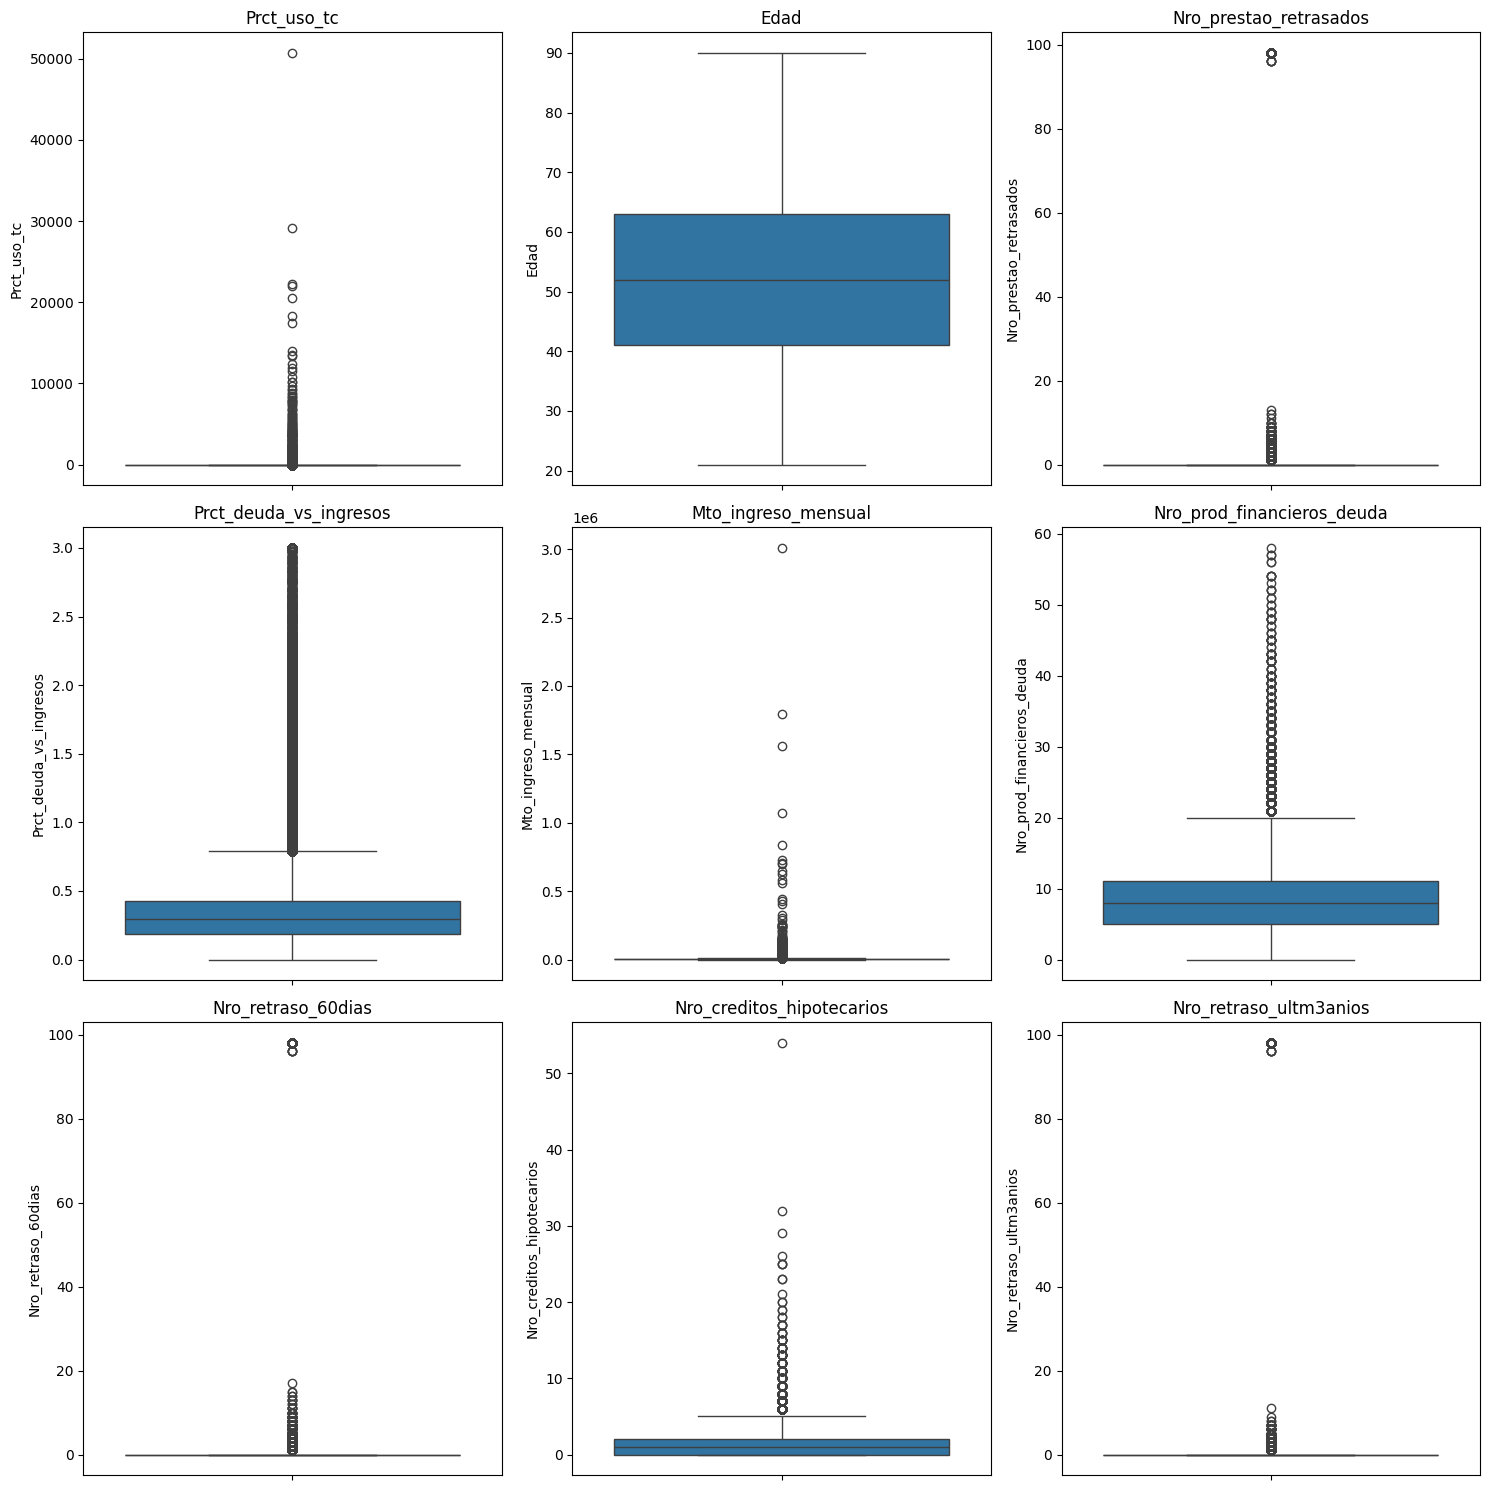

In [22]:
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=credit_df[col], ax=axes[i])
    axes[i].set_title(col)
    
# Eliminar ejes vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insights**:

- ``Prct_uso_tc``
    - Caja comprimida cerca de 0.
    - Muchos valores extremos enormes (hasta ~50000).
    - No tiene sentido económico si es porcentaje.
    - Esto no es simplemente asimetría. Hay valores claramente erróneos o mal escalados.
    - **Requiere limitación de valores severo o winsorización fuerte. Podría incluso limitarse a rango [0, 5] o [0, 10].**

- ``Edad``
    - Distribución muy limpia. Sin outliers problemáticos.
    - Rango lógico (18–90 después de limpieza).

- ``Nro_prestao_retrasados``
    - 75% en 0.
    - Cola derecha larga (hasta ~100). Conteo discreto.
    - No son “outliers” en sentido estadístico. Son clientes extremadamente riesgosos.
    - Aquí no conviene winsorizar agresivamente. En riesgo, valores altos son señal real.

- ``Prct_deuda_vs_ingresos``
    - Con el tratamiento aplicado, quedó razonable.
    - Variable clave.

- ``Mto_ingreso_mensual``
    - Altísima asimetría. 
    - Outliers enormes.
    - Cola derecha muy larga.
    - Ingresos reales pueden variar mucho. Pero esos millones extremos pueden distorsionar modelos lineales.
    - **Justificado usar log transform.**
    - **Winsorización suave (p99) recomendable.**

- ``Nro_prod_financieros_deuda``
    - Mediana ~8.
    - Cola hasta 60.
    - Distribución lógica. No parece error. Son clientes con muchos productos.

- ``Nro_retraso_60dias``
    - Mayoría 0.
    - Algunos extremos (~100). Discreta.
    - En riesgo, valores altos son señal fuerte.
    - No winsorizar. Dejar como está.

- ``Nro_creditos_hipotecarios``
    - Mismo patrón que otras moras. No tocar.

- ``Nro_dependiente``
    - Mayoría 0–1. 
    - Algunos hasta 20. No parece error.
    - No requiere winsorización.

In [23]:
# Outliers (winsorización suave para variables continuas)

def winsorize(series, lower=0.01, upper=0.99):
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lo, hi)

# Prct_uso_tc puede tener outliers muy grandes
if "Prct_uso_tc" in credit_df.columns:
    credit_df["Prct_uso_tc"] = winsorize(credit_df["Prct_uso_tc"])
    credit_df["Prct_uso_tc"] = credit_df["Prct_uso_tc"].clip(lower=0)  # % no negativo

# Calcular percentil 99
upper_cap = credit_df["Mto_ingreso_mensual"].quantile(0.99)
# Aplicar winsorización superior
credit_df["Mto_ingreso_mensual"] = credit_df["Mto_ingreso_mensual"].clip(upper=upper_cap)

# Ingreso (ya imputado) también puede tener cola pesada
credit_df[inc_col] = winsorize(credit_df[inc_col])

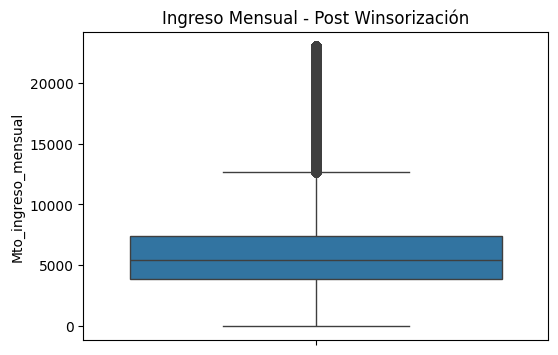

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(y=credit_df["Mto_ingreso_mensual"])
plt.title("Ingreso Mensual - Post Winsorización")
plt.show()

In [25]:
credit_df["log_ingreso"] = np.log1p(credit_df["Mto_ingreso_mensual"])
credit_df.drop(columns=["Mto_ingreso_mensual"], inplace=True)

**Insights**:

Se generó la variable log_ingreso para reducir asimetría y mejorar estabilidad del modelo. Se elimina Mto_ingreso_mensual para evitar redundancia y colinealidad

In [26]:
# Chequeos finales de calidad
# Sin nulos en variables críticas (target y numéricas)
critical_cols = ["Default", "Edad", inc_col, ratio_col, "Prct_uso_tc", "log_ingreso"]
existing_critical = [c for c in critical_cols if c in credit_df.columns]
na_check = credit_df[existing_critical].isnull().sum()

display(na_check)

# Validación simple: no negativos en variables de conteo (tras imputación/clip)
for c in count_cols:
    if c in credit_df.columns:
        assert (credit_df[c].dropna() >= 0).all(), f"Valores negativos persistentes en {c}"

Default                   0
Edad                      0
Prct_deuda_vs_ingresos    0
Prct_uso_tc               0
log_ingreso               0
dtype: int64

In [27]:
# Vista final
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149999 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Default                     149999 non-null  int64  
 1   Prct_uso_tc                 149999 non-null  float64
 2   Edad                        149999 non-null  int64  
 3   Nro_prestao_retrasados      149999 non-null  float64
 4   Prct_deuda_vs_ingresos      149999 non-null  float64
 5   Nro_prod_financieros_deuda  149999 non-null  float64
 6   Nro_retraso_60dias          149999 non-null  float64
 7   Nro_creditos_hipotecarios   149999 non-null  float64
 8   Nro_retraso_ultm3anios      149999 non-null  float64
 9   Nro_dependiente             149999 non-null  int32  
 10  log_ingreso                 149999 non-null  float64
dtypes: float64(8), int32(1), int64(2)
memory usage: 13.2 MB


In [28]:
count_cols = [
    "Nro_prestao_retrasados",
    "Nro_prod_financieros_deuda",
    "Nro_retraso_60dias",
    "Nro_creditos_hipotecarios",
    "Nro_retraso_ultm3anios"
]

for c in count_cols:
    credit_df[c] = credit_df[c].round().astype("int32")

In [29]:
credit_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Default,149999.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.000000
Prct_uso_tc,149999.0,0.320491,0.352149,0.0,0.029867,0.154176,0.559044,1.092958
Edad,149999.0,52.285235,14.743048,21.0,41.000000,52.000000,63.000000,90.000000
Nro_prestao_retrasados,149999.0,0.421029,4.192795,0.0,0.000000,0.000000,0.000000,98.000000
Prct_deuda_vs_ingresos,149999.0,0.387257,0.455462,0.0,0.183708,0.296023,0.425508,3.000000
Nro_prod_financieros_deuda,149999.0,8.452776,5.145964,0.0,5.000000,8.000000,11.000000,58.000000
Nro_retraso_60dias,149999.0,0.265975,4.169318,0.0,0.000000,0.000000,0.000000,98.000000
Nro_creditos_hipotecarios,149999.0,1.018233,1.129772,0.0,0.000000,1.000000,2.000000,54.000000
Nro_retraso_ultm3anios,149999.0,0.240388,4.155193,0.0,0.000000,0.000000,0.000000,98.000000
Nro_dependiente,149999.0,0.737405,1.107020,0.0,0.000000,0.000000,1.000000,20.000000


**Insights**:

- No hay valores negativos indebidos
- No hay outliers explosivos
- Ratios están contenidos
- Variables de conteo mantienen señal real
- Distribuciones coherentes con contexto bancario

# 2. Análisis descriptivo (univariado/bivariado)

## 2.1 Análisis Descriptivo – Univariado

Esto nos permite entender:

- Distribución de cada variable
- Asimetría
- Concentración
- Señales potenciales de riesgo
- Calidad estadística

### 2.1.1 Variable Objetivo (Default)

In [30]:
credit_df["Default"].value_counts(normalize=True)

Default
0    0.93316
1    0.06684
Name: proportion, dtype: float64

**Insights**

- Dataset fuertemente desbalanceado: ~6.7% default (clase positiva), ~93.3% no Default (clase negativa)
- Accuracy no será útil (Predicciones correctas / Total de observaciones, no distingue entre clases. La clase minoritaria es la que importa. Es la que genera pérdidas. Un modelo que no detecta defaults no es bueno, aunque tenga un accuracy alto por acertar los casos de no default)
- Necesitamos ROC-AUC, GINI, Recall, Precision-Recall AUC
- Necesidad de threshold optimizado

### 2.1.2 Variables Continuas

**``log_ingreso``**

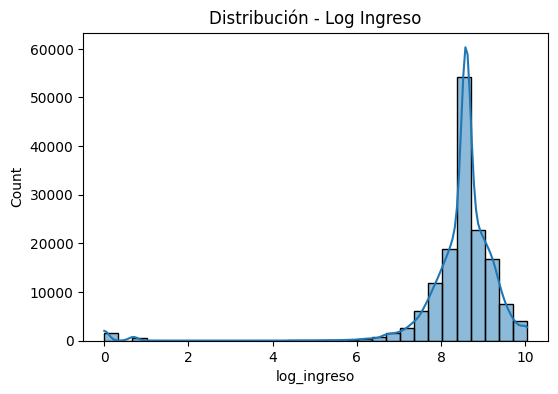

In [31]:
plt.figure(figsize=(6,4))
sns.histplot(credit_df["log_ingreso"], bins=30, kde=True)
plt.title("Distribución - Log Ingreso")
plt.show()

**Insights**

- Distribución mucho más simétrica que el ingreso original.
- Distribución claramente concentrada entre 8 y ~9.5.
- Pico pronunciado alrededor de ~8.5, 8.8.
- Se observan algunos valores muy pequeños (cerca de 0):
    - log_ingreso=log(1+ingreso), si log_ingreso ≈ 0 ⇒ ingreso ≈ 0
    - Eso significa que hay clientes con ingreso extremadamente bajo o cero.
    - En crédito retail:
        - Puede haber clientes sin ingresos formales
        - Puede haber errores de captura
        - Puede ser ingreso mínimo declarado
        - Pero debemos verificar si esos casos: Son muchos y si están asociados a mayor default.

In [32]:
# % de casos tienen ingreso cercano a cero
(credit_df["log_ingreso"] < 1).mean()*100

1.492676617844119

In [33]:
# Tasa de default
credit_df.loc[
    credit_df["log_ingreso"] < 1,
    "Default"
].mean()*100

3.707012058954891

**Insights**

- Muy pocos clientes tienen ingreso cercano a cero (1.49% del dataset)
- Tasa de default global ≈ 6.68%, tasa de default en ingreso cercano a cero ≈ 3.7% => Los clientes con ingreso extremadamente bajo NO tienen mayor default. De hecho, tienen menor tasa que el promedio.
- Puede tratarse de clientes jóvenes sin historial fuerte.
- Puede haber capturas incompletas de ingreso.
- El riesgo en este dataset parece estar más explicado por comportamiento pasado que por nivel de ingreso.
- Por lo que no se justifica un tratamiento adicional específico.

**``Prct_deuda_vs_ingresos``**

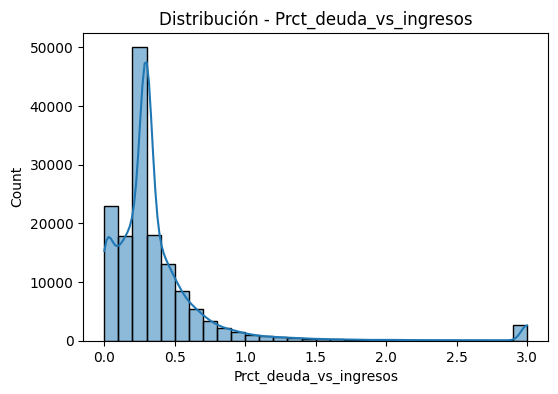

In [34]:
plt.figure(figsize=(6,4))
sns.histplot(credit_df["Prct_deuda_vs_ingresos"], bins=30, kde=True)
plt.title("Distribución - Prct_deuda_vs_ingresos")
plt.show()

**Insights**

- Distribución claramente asimétrica a la derecha.
- Alta concentración entre 0.1 y 0.5.
- Cola que se extiende hasta 3 (cap aplicado).
- Pequeña acumulación en el valor máximo (3), producto del corte realizado (Valores >300% no tienen interpretación real. Evita que el modelo aprenda ruido extremo.)
- La mayoría de clientes tiene:
    - Ratio deuda/ingreso < 50%
    - Un grupo menor entre 50% y 100%
    - Una minoría sobreendeudada (>100%)
    - Implica potencial poder discriminante

**``Prct_uso_tc``**

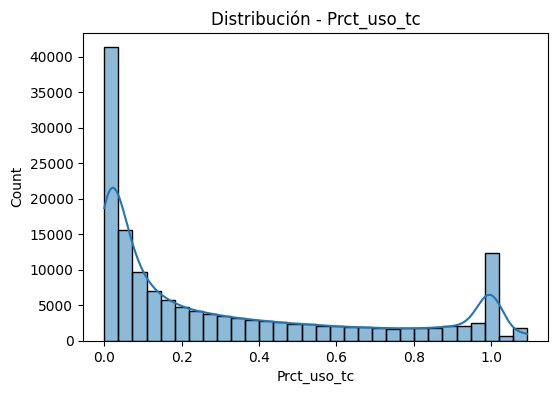

In [35]:
plt.figure(figsize=(6,4))
sns.histplot(credit_df["Prct_uso_tc"], bins=30, kde=True)
plt.title("Distribución - Prct_uso_tc")
plt.show()

**Insights**
- Alta concentración cerca de 0.
- Cola progresiva entre 0.1 y 0.8.
- Segundo “pico” cercano a 1 (uso cercano al 100%).
- Esto no es una distribución normal.
- Es claramente asimétrica y posiblemente bimodal.
- Podemos interpretar tres segmentos claros (lo que sugiere potencial capacidad discriminante en términos de riesgo):
    - Segmento 1 (verde): Uso bajo (0–20%). Clientes con baja utilización de tarjeta. Probablemente con mayor holgura financiera.
    - Segmento 2 (amarillo): Uso medio (20–80%). Clientes con uso activo pero controlado.
    - Segmento 3 (rojo): Uso alto (≈100%). Clientes que están al límite de su línea de crédito. Este último segmento suele ser altamente relevante en riesgo.

**Variables Discretas (Conteos)**

Aquí no usamos histograma tradicional, sino conteo.

**``Nro_retraso_60dias`` (Mora > 60 días)**

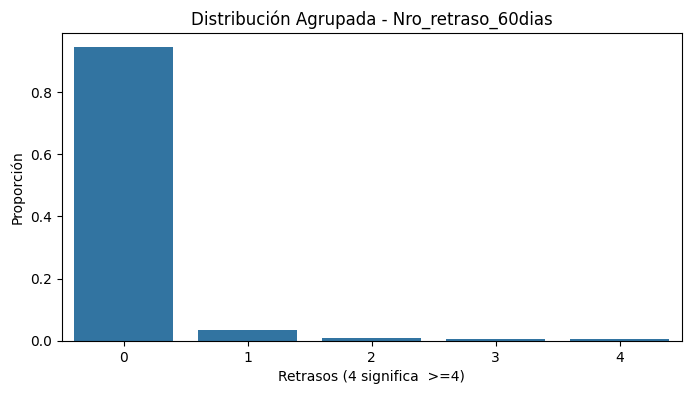

In [36]:
credit_df["retraso_60_grouped"] = credit_df["Nro_retraso_60dias"].apply(
    lambda x: x if x <= 3 else 4
)

vc_grouped = credit_df["retraso_60_grouped"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=vc_grouped.index, y=vc_grouped.values)
plt.title("Distribución Agrupada - Nro_retraso_60dias")
plt.ylabel("Proporción")
plt.xlabel("Retrasos (4 significa  >=4)")
plt.show()

**Insights**
- ~94–95% de los clientes tienen 0 retrasos >60 días.
- ~3–4% tienen 1 retraso.
- El resto (2, 3, ≥4) es marginal.
- La mayoría de clientes cumple. El riesgo está concentrado en minoría. => Potencial alta capacidad discriminante.

**``Nro_retraso_ultm3anios`` (Mora últimos 3 años)** 

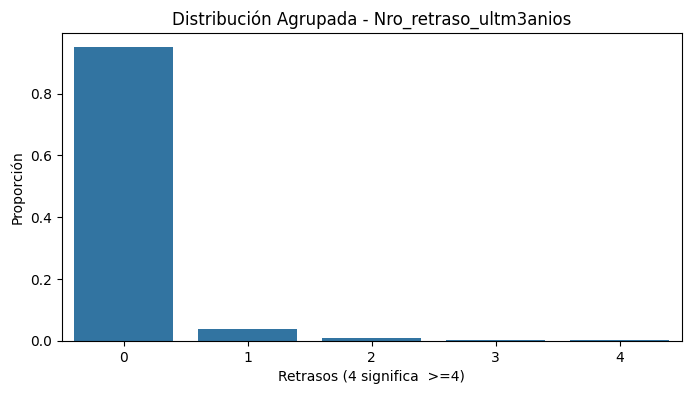

In [37]:
credit_df["retraso_ultm3anios_grouped"] = credit_df["Nro_retraso_ultm3anios"].apply(
    lambda x: x if x <= 3 else 4
)

vc_grouped = credit_df["retraso_ultm3anios_grouped"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=vc_grouped.index, y=vc_grouped.values)
plt.title("Distribución Agrupada - Nro_retraso_ultm3anios")
plt.ylabel("Proporción")
plt.xlabel("Retrasos (4 significa  >=4)")
plt.show()

**Insights**
- Mismo análisis que ``Nro_retraso_60dias``.

**``Nro_prod_financieros_deuda`` (Productos financieros)**

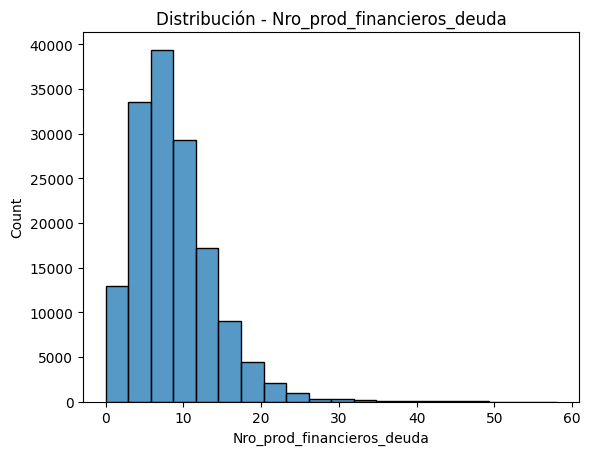

In [38]:
sns.histplot(credit_df["Nro_prod_financieros_deuda"], bins=20)
plt.title("Distribución - Nro_prod_financieros_deuda")
plt.show()

**Insights**

- Distribución unimodal.
- Pico entre 5 y 10 productos.
- Cola derecha hasta ~60.
- Asimetría moderada, no extrema.
- Su relación con el riesgo no es trivial y requiere análisis bivariado.

**``Nro_dependiente`` (Carga familiar)** 

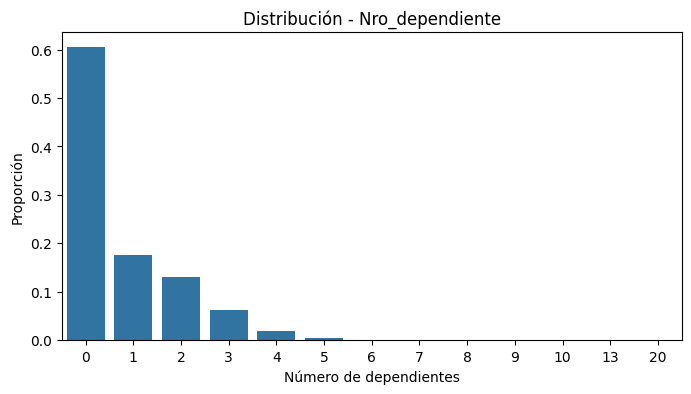

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular proporciones ordenadas
dep_dist = (
    credit_df["Nro_dependiente"]
    .value_counts(normalize=True)
    .sort_index()
)

plt.figure(figsize=(8,4))
sns.barplot(x=dep_dist.index, y=dep_dist.values)

plt.title("Distribución - Nro_dependiente")
plt.xlabel("Número de dependientes")
plt.ylabel("Proporción")
plt.show()

**Insights**

- ~60% tienen 0 dependientes. Distribución altamente concentrada en valores bajos.
- ~17–18% tienen 1
- ~12–13% tienen 2
- A partir de 3 cae rápidamente
- Cola muy pequeña hasta 20
- No es obvia la relación con el riesgo, ver análisis bivariado.


## 2.2 Análisis Descriptivo – Bivariado

Esto nos permite:

- Medir capacidad discriminante
- Buscar relaciones monotónicas
- Detectar no linealidades
- Identificar posibles transformaciones
- Entender drivers reales del default

**Comenzamos por el driver más fuerte: Mora >60 días (``Nro_retraso_60dias``)**

In [40]:
# Tasa de default por número de retrasos
risk_60 = (
    credit_df
    .groupby("Nro_retraso_60dias")["Default"]
    .agg(["count", "mean"])
    .reset_index()
)

# Renombrar y convertir a porcentaje
risk_60.rename(columns={"mean": "default_rate_pct"}, inplace=True)
risk_60["default_rate_pct"] = risk_60["default_rate_pct"].round(2)*100

risk_60.head(10)

,Nro_retraso_60dias,count,default_rate_pct
0,0,141661,5.0
1,1,5243,34.0
2,2,1555,50.0
3,3,667,58.0
4,4,291,67.0
5,5,131,63.0
6,6,80,60.0
7,7,38,82.0
8,8,21,71.0
9,9,19,74.0


**Insights**

- El salto de riesgo entre:
    - 0 retrasos → 4.6%
    - 1 retraso → 33.7%

    Es brutal.

- Multiplica el riesgo por más de 7 veces.
- Esto solo ya explica una enorme parte del modelo.
- El gráfico muestra un punto extraño (100 retrasos), eso indica que:
    - Hay valores extremos muy raros.
    - Probablemente errores de captura o dataset sintético.
    - Pero como el count es muy bajo, no afectan el modelo significativamente.
- ``Nro_retraso_60dias`` es altamente discriminante, candidata fuerte a top variable del modelo.

**Mora últimos 3 años (>30 días)**

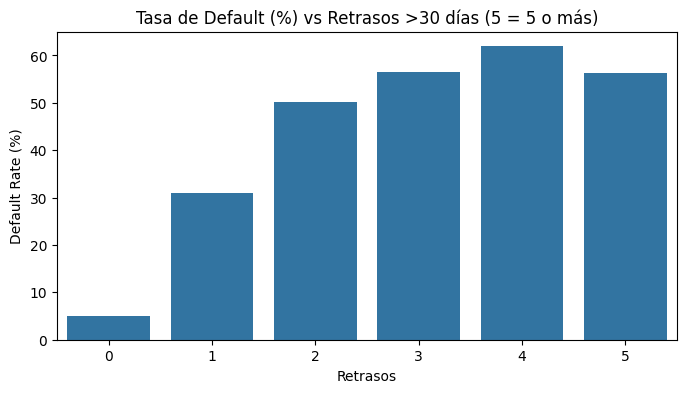

In [41]:
credit_df["retraso_30_grouped"] = credit_df["Nro_retraso_ultm3anios"].apply(
    lambda x: x if x <= 4 else 5
)

risk_30_grouped = (
    credit_df
    .groupby("retraso_30_grouped")["Default"]
    .mean()
    .reset_index()
)

risk_30_grouped["default_rate_pct"] = (risk_30_grouped["Default"] * 100).round(2)

plt.figure(figsize=(8,4))
sns.barplot(
    data=risk_30_grouped,
    x="retraso_30_grouped",
    y="default_rate_pct"
)

plt.title("Tasa de Default (%) vs Retrasos >30 días (5 = 5 o más)")
plt.xlabel("Retrasos")
plt.ylabel("Default Rate (%)")
plt.show()

**Insights**
- El salto entre:
    - 0 retrasos → ~5%
    - 1 retraso → ~31%

    Es masivo.

- Multiplica el riesgo por más de 6 veces.
- Esto es señal muy fuerte. Alto poder discriminante

**Ratio Deuda / Ingresos (variable continua)**

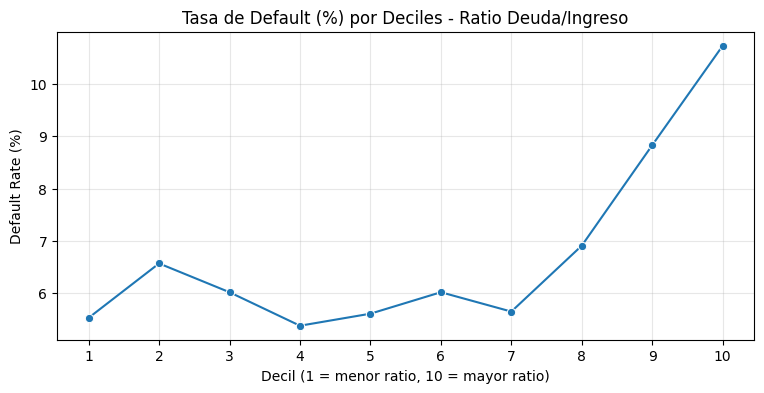

,ratio_decile,default_rate_pct
0,1,5.53
1,2,6.57
2,3,6.02
3,4,5.38
4,5,5.61
5,6,6.02
6,7,5.65
7,8,6.91
8,9,8.83
9,10,10.73


In [42]:
# 1) Crear deciles numéricos (1 = menor ratio, 10 = mayor ratio)
credit_df["ratio_decile"] = (
    pd.qcut(
        credit_df["Prct_deuda_vs_ingresos"],
        q=10,
        labels=False,
        duplicates="drop"
    )
    .astype(int) + 1
)

# 2) Calcular default rate por decil (en %)
ratio_risk = (
    credit_df
    .groupby("ratio_decile")["Default"]
    .mean()
    .reset_index()
    .sort_values("ratio_decile")
)

ratio_risk["default_rate_pct"] = (ratio_risk["Default"] * 100).round(2)

# 3) Graficar (más legible que intervalos)
plt.figure(figsize=(9,4))
sns.lineplot(
    data=ratio_risk,
    x="ratio_decile",
    y="default_rate_pct",
    marker="o"
)

plt.title("Tasa de Default (%) por Deciles - Ratio Deuda/Ingreso")
plt.xlabel("Decil (1 = menor ratio, 10 = mayor ratio)")
plt.ylabel("Default Rate (%)")
plt.xticks(range(int(ratio_risk["ratio_decile"].min()), int(ratio_risk["ratio_decile"].max()) + 1))
plt.grid(True, alpha=0.3)
plt.show()

# tabla resumen
ratio_risk[["ratio_decile", "default_rate_pct"]]

**Insights**
- Ratio deuda:
    - Salto de 6% → 10% (moderado)
- Conclusión: Ratio deuda aporta señal adicional, pero no domina.

**``log_ingreso`` vs ``Default``**

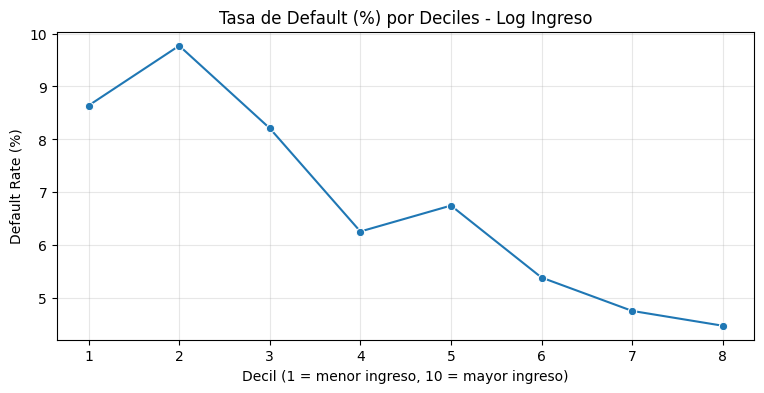

,ingreso_decile,default_rate_pct
0,1,8.64
1,2,9.77
2,3,8.21
3,4,6.26
4,5,6.75
5,6,5.39
6,7,4.76
7,8,4.48


In [43]:
# 1) Crear deciles (1 = menor ingreso, 10 = mayor ingreso)
credit_df["ingreso_decile"] = (
    pd.qcut(
        credit_df["log_ingreso"],
        q=10,
        labels=False,
        duplicates="drop"
    ).astype(int) + 1
)

# 2) Calcular default rate por decil (en %)
ingreso_risk = (
    credit_df
    .groupby("ingreso_decile")["Default"]
    .mean()
    .reset_index()
    .sort_values("ingreso_decile")
)

ingreso_risk["default_rate_pct"] = (ingreso_risk["Default"] * 100).round(2)

# 3) Graficar
plt.figure(figsize=(9,4))
sns.lineplot(
    data=ingreso_risk,
    x="ingreso_decile",
    y="default_rate_pct",
    marker="o"
)

plt.title("Tasa de Default (%) por Deciles - Log Ingreso")
plt.xlabel("Decil (1 = menor ingreso, 10 = mayor ingreso)")
plt.ylabel("Default Rate (%)")
plt.xticks(range(int(ingreso_risk["ingreso_decile"].min()), int(ingreso_risk["ingreso_decile"].max()) + 1))
plt.grid(True, alpha=0.3)
plt.show()

# tabla resumen
ingreso_risk[["ingreso_decile", "default_rate_pct"]]

**Insights**

- Deciles bajos (1–3) → mayor tasa de default (~8–10%)
- A mayor ingreso → menor probabilidad de default.
- Deciles altos (~7–8) → ~4.5%
- Hay una relación inversa bastante clara.

**Uso de tarjeta (``Prct_uso_tc``)**

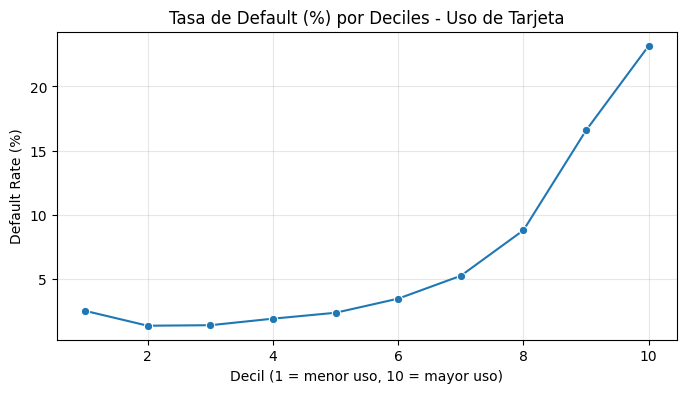

,uso_tc_decile,Default,default_rate_pct
0,1,0.025200,2.52
1,2,0.013600,1.36
2,3,0.014000,1.40
3,4,0.019133,1.91
4,5,0.023733,2.37
5,6,0.034736,3.47
6,7,0.052467,5.25
7,8,0.088000,8.80
8,9,0.165800,16.58
9,10,0.231733,23.17


In [44]:
# Crear deciles
credit_df["uso_tc_decile"] = (
    pd.qcut(
        credit_df["Prct_uso_tc"],
        q=10,
        labels=False,
        duplicates="drop"
    ).astype(int) + 1
)

# Calcular default rate por decil
uso_tc_risk = (
    credit_df
    .groupby("uso_tc_decile")["Default"]
    .mean()
    .reset_index()
)

uso_tc_risk["default_rate_pct"] = (uso_tc_risk["Default"] * 100).round(2)

# Graficar
plt.figure(figsize=(8,4))
sns.lineplot(
    data=uso_tc_risk,
    x="uso_tc_decile",
    y="default_rate_pct",
    marker="o"
)

plt.title("Tasa de Default (%) por Deciles - Uso de Tarjeta")
plt.xlabel("Decil (1 = menor uso, 10 = mayor uso)")
plt.ylabel("Default Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()

uso_tc_risk

**Insights**
- Observamos claramente:
    - Deciles 1–4 → riesgo muy bajo (~1–2%)
    - Deciles 5–7 → incremento moderado
    - Deciles 8–10 → salto fuerte
    - Decil 10 → ~23% default
- Clientes con uso cercano al 100%:
    - Menor liquidez disponible
    - Mayor dependencia del crédito rotativo
    - Mayor vulnerabilidad financiera
- Candidato top del modelo

**Número de productos financieros**

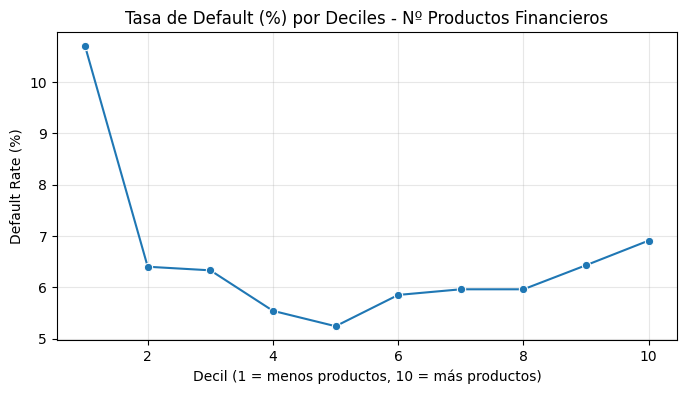

,prod_decile,Default,default_rate_pct
0,1,0.107029,10.70
1,2,0.064002,6.40
2,3,0.063336,6.33
3,4,0.055388,5.54
4,5,0.052428,5.24
5,6,0.058476,5.85
6,7,0.059643,5.96
7,8,0.059572,5.96
8,9,0.064295,6.43
9,10,0.069073,6.91


In [45]:
# Crear deciles
credit_df["prod_decile"] = (
    pd.qcut(
        credit_df["Nro_prod_financieros_deuda"],
        q=10,
        labels=False,
        duplicates="drop"
    ).astype(int) + 1
)

# Calcular default rate por decil
prod_risk = (
    credit_df
    .groupby("prod_decile")["Default"]
    .mean()
    .reset_index()
)

prod_risk["default_rate_pct"] = (prod_risk["Default"] * 100).round(2)

# Graficar
plt.figure(figsize=(8,4))
sns.lineplot(
    data=prod_risk,
    x="prod_decile",
    y="default_rate_pct",
    marker="o"
)

plt.title("Tasa de Default (%) por Deciles - Nº Productos Financieros")
plt.xlabel("Decil (1 = menos productos, 10 = más productos)")
plt.ylabel("Default Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()

prod_risk

**Insights**
- El mayor riesgo no está en quienes tienen muchos productos. Está en quienes tienen muy pocos.
- Esto es interesante desde negocio: Poca bancarización puede asociarse a mayor riesgo.
- Aporta información para el modelo.


**Estado actual del análisis bivariado**

Hasta ahora, ranking preliminar de drivers:

1️ - Mora >60 días

2 - Uso de tarjeta

3 - Mora >30 días

4 - Ratio deuda

5 - Ingreso

6️ - Nº productos

# 3 . Modelamiento (03 modelos)

**Objetivo**

Construir y comparar 3 modelos:

1- Logistic Regression (baseline interpretable)

2 - Random Forest (modelo no lineal robusto)

3️ - LightGBM (modelo avanzado de boosting)

Evaluando con:

- ROC-AUC
- GINI
- Recall
- Cutoff óptimo (treshold)

## 3.1 Preparación para modelar

In [46]:
credit_df = credit_df.drop(columns=['ratio_bin', 'ingreso_bin', 'retraso_60_grouped', 'retraso_ultm3anios_grouped',
       'retraso_30_grouped', 'ratio_decile', 'ingreso_decile', 'uso_tc_decile',
       'prod_decile'], errors="ignore")
credit_df.columns

Index(['Default', 'Prct_uso_tc', 'Edad', 'Nro_prestao_retrasados',
       'Prct_deuda_vs_ingresos', 'Nro_prod_financieros_deuda',
       'Nro_retraso_60dias', 'Nro_creditos_hipotecarios',
       'Nro_retraso_ultm3anios', 'Nro_dependiente', 'log_ingreso'],
      dtype='object')

### 3.1.1 Definir X e y

In [47]:
X = credit_df.drop(columns=["Default"])
y = credit_df["Default"]

### 3.1.2 Train/Test Split (estratificado)

Muy importante en dataset desbalanceado.

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

### 3.1.3. Escalado (solo para Logistic)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3.2 Modelos

Dado que el dataset presenta un fuerte desbalance (~6.7% default), la accuracy no es una métrica adecuada ya que un modelo trivial podría obtener alta accuracy sin capturar eventos de incumplimiento. Por ello se priorizan métricas como AUC, GINI y Recall.

### 3.2.1 Modelo 1 — Logistic Regression

**Entrenamiento**

In [50]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

**Evaluación**

In [51]:
from sklearn.metrics import roc_auc_score

y_pred_proba_log = log_model.predict_proba(X_test_scaled)[:,1]

auc_log = roc_auc_score(y_test, y_pred_proba_log)
gini_log = 2 * auc_log - 1

print("AUC Logistic Reg.: ", auc_log.round(2))
print("GINI Logistic Reg.: ", gini_log.round(2))

AUC Logistic Reg.:  0.83
GINI Logistic Reg.:  0.66


**Insights**

- Un AUC = 0.83 y GINI = 0.66 para una Logistic Regression en riesgo crediticio es un muy buen resultado.
- AUC = 0.83 => Si tomas un cliente que hizo default y uno que no, hay un 83% de probabilidad de que el modelo le asigne mayor score al que hizo default. El modelo es bueno ordenando clientes de: menos riesgoso → más riesgoso. No es una predicción binaria aún.
Es una capacidad de ordenar por nivel de riesgo.
- GINI = 0.66 => Es fuerte para un modelo base, la métrica es buena. El modelo discrimina muy bien clientes sin default de los que si tienen default.
- Este resultado indica que:
    - El dataset tiene señal real.
    - Las variables seleccionadas son potentes.
    - La relación es suficientemente lineal como para que Logistic capture bien el patrón.
    - El modelo tiene alta capacidad de discriminación entre clientes con y sin incumplimiento.

### 3.2.2 Modelo 2 — Random Forest

**Entrenamiento**

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_proba_rf = rf_model.predict_proba(X_test)[:,1]

**Evaluación**

In [53]:
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
gini_rf = 2 * auc_rf - 1

print("AUC RF.: ", auc_rf.round(2))
print("GINI RF: ", gini_rf.round(2))

AUC RF.:  0.86
GINI RF:  0.72


**Insights**

- AUC pasó de 0.83 → 0.86
- GINI pasó de 0.66 → 0.72. Muy alto poder discriminante.
- Mejora de +0.03 AUC.
- Random Forest mejora porque:
    - Captura relaciones no lineales.
    - Detecta interacciones.
    - No necesita supuestos lineales como Logistic.
    - Maneja mejor efectos tipo umbral (como uso de tarjeta alto).
- Debemos:
    - Compararlo con LightGBM.
    - Revisar overfitting.
    - Evaluar recall.
    - Definir cutoff óptimo.

### 3.2.3 Modelo 3 — LightGBM

**Entrenamiento**

In [54]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42
)

lgb_model.fit(X_train, y_train)

y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 7018, number of negative: 97981
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002914 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 959
[LightGBM] [Info] Number of data points in the train set: 104999, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


**Evaluación**

In [55]:
auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
gini_lgb = 2 * auc_lgb - 1

print("AUC LGBM.: ", auc_lgb.round(2))
print("GINI LGBM: ", gini_lgb.round(2))

AUC LGBM.:  0.86
GINI LGBM:  0.73


In [56]:
# Asegúrate de tener calculadas estas variables:
# auc_log, gini_log
# auc_rf,  gini_rf
# auc_lgb, gini_lgb

results = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest", "LightGBM"],
    "AUC":    [auc_log, auc_rf, auc_lgb],
    "GINI":   [gini_log, gini_rf, gini_lgb],
})

# Redondeo y orden por performance
results = results.sort_values("AUC", ascending=False).reset_index(drop=True)
results[["AUC", "GINI"]] = results[["AUC", "GINI"]].round(2)

results

,Modelo,AUC,GINI
0,LightGBM,0.86,0.73
1,Random Forest,0.86,0.72
2,Logistic Regression,0.83,0.66


**Insights**

- AUC igual a RF (0.86)
- GINI ligeramente superior (0.73 vs 0.72)
- La diferencia es pequeña pero consistente.
- De Logistic → LightGBM:
    - +0.03 AUC
    - +0.07 GINI
-  Esta mejora puede representar:
    - Mejor segmentación de riesgo
    - Menor tasa de default en cartera aprobada
    - Mejor rentabilidad ajustada por riesgo
    

### 3.2.4 Siguiente paso crítico

Ahora viene lo más importante del challenge:

1️ - Curva ROC comparativa

2️ - Definir cutoff óptimo

3️ - Evaluar Recall

4️ - Diseñar estrategia de aprobación

Porque AUC solo mide ranking.

El negocio decide con cutoff.

#### 3.2.4.1 Curva ROC comparativa

Visualizar capacidad de discriminación de los tres modelos en un mismo gráfico.

Eje X → False Positive Rate (FPR)

Eje Y → True Positive Rate (TPR / Recall)

La línea diagonal es modelo aleatorio.

Cuanto más se aleje hacia arriba la curva → mejor discriminación.

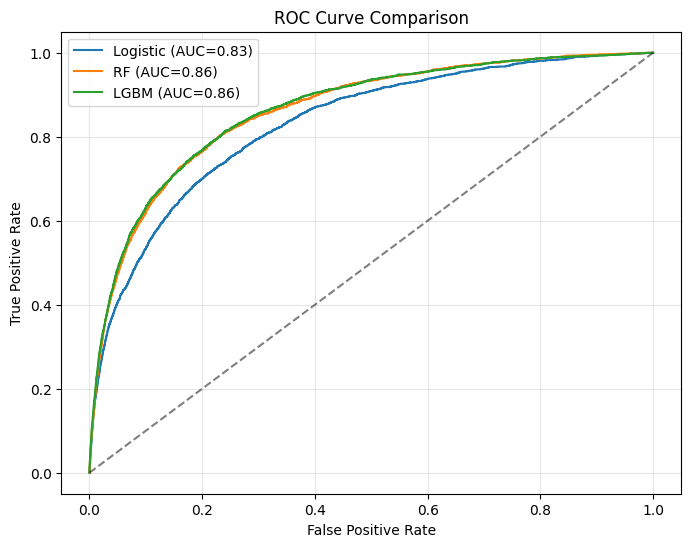

In [57]:
from sklearn.metrics import roc_curve

# Calcular curvas ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_proba_lgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.2f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LGBM (AUC={auc_lgb:.2f})")

plt.plot([0,1],[0,1],'k--', alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Insights**

- Logistic (azul) consistentemente por debajo.
- RF (naranja) y LGBM (verde) prácticamente superpuestos. 
- LGBM levemente superior en algunas zonas.
- En crédito no nos importa toda la curva. Nos importa la zona de: Bajo False Positive Rate (ej. 5%–20%) => Alta detección de malos con pocos falsos positivos
    - En esa zona: RF y LGBM dominan claramente.
    - Logistic pierde capacidad de detección temprana.
- Performance ranking:
    - 1. LightGBM
    - 2. Random Forest
    - 3. Logistic

Pero RF y LGBM están prácticamente empatados.

#### 3.2.4.2 Comparativa completa de métricas

- AUC
- GINI
- Cutoff óptimo
- Recall
- Precision
- Approval rate

En riesgo crediticio no usamos 0.5. Podemos usar el método "Maximizar Youden Index", este cutoff equilibra sensibilidad y especificidad.

También podría usarse una tasa de aprobación objetivo. Ejemplo: aprobar 70% de clientes. Pero no contamos con esa definición.

Recall responde: ¿Qué porcentaje de los default estamos detectando?

En riesgo esto es clave.

In [58]:
from sklearn.metrics import roc_auc_score, roc_curve, recall_score, precision_score

def evaluate_model(y_true, y_proba, model_name):
    # AUC / GINI
    auc = roc_auc_score(y_true, y_proba)
    gini = 2 * auc - 1

    # Cutoff óptimo (Youden)
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    cutoff = thresholds[best_idx]

    # Predicción binaria según cutoff
    y_pred = (y_proba >= cutoff).astype(int)

    # Métricas
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)

    # Approval rate (asumiendo que "aprobado" = score < cutoff, es decir no predice default)
    approval_rate = (y_proba < cutoff).mean()

    return {
        "Modelo": model_name,
        "AUC": auc,
        "GINI": gini,
        "Cutoff_Optimo": cutoff,
        "Recall": recall,
        "Precision": precision,
        "Approval_Rate": approval_rate
    }

# --- Evaluación de los 3 modelos ---
rows = []
rows.append(evaluate_model(y_test, y_pred_proba_log, "Logistic Regression"))
rows.append(evaluate_model(y_test, y_pred_proba_rf, "Random Forest"))
rows.append(evaluate_model(y_test, y_pred_proba_lgb, "LightGBM"))

results = pd.DataFrame(rows)

# Formato/orden
results = results.sort_values("AUC", ascending=False).reset_index(drop=True)
results[["AUC","GINI","Cutoff_Optimo","Recall","Precision"]] = results[
    ["AUC","GINI","Cutoff_Optimo","Recall","Precision"]
].astype(float).round(2)



# Approval en %
results["Approval_Rate_%"] = (results["Approval_Rate"] * 100).round(2)

results

,Modelo,AUC,GINI,Cutoff_Optimo,Recall,Precision,Approval_Rate,Approval_Rate_%
0,LightGBM,0.86,0.73,0.42,0.81,0.19,0.720000,72.00
1,Random Forest,0.86,0.72,0.47,0.80,0.20,0.729044,72.90
2,Logistic Regression,0.83,0.66,0.51,0.73,0.19,0.738844,73.88


**Insights**

- LightGBM es más fuerte técnicamente:
    - Mayor GINI (0.73)
    - Mayor Recall (0.81). Detecta 81% de los malos (default).
    - Misma AUC que RF
    - Menor approval ligeramente (más conservador). Approval_Rate_%: LGBM aprobaría 72% de las solicitudes de crédito. Rechazaría 28%.
- Es el modelo con mayor poder discriminante.
- **Modelo seleccionado para optimización por hiperparámetros: LightGBM**

# 4. Optimización de hiperametros, 5. Inferencias y 6. Métricas de performance


Como objetivo, buscamos mejorar:

- AUC / GINI
- Recall
- Estabilidad
- Generalización (evitar overfitting)

En LightGBM, los hiperparámetros críticos son:

### Parámetros Críticos – LightGBM

| Parámetro | Impacto en el Modelo |
|------------|----------------------|
| `n_estimators` | Número total de árboles. Más árboles pueden mejorar performance pero aumentan riesgo de sobreajuste. |
| `learning_rate` | Velocidad de aprendizaje. Valores bajos requieren más árboles pero suelen generalizar mejor. |
| `num_leaves` | Controla la complejidad del árbol. Más hojas = mayor capacidad de capturar patrones no lineales. |
| `max_depth` | Limita la profundidad del árbol. Ayuda a prevenir overfitting. |
| `min_child_samples` | Número mínimo de observaciones por hoja. Actúa como regularización. |
| `subsample` | Proporción de datos usados por árbol. Reduce varianza y overfitting. |
| `colsample_bytree` | Proporción de variables usadas por árbol. Aumenta diversidad del modelo. |
| `class_weight` | Ajuste para desbalance de clases. Mejora detección de la clase minoritaria (default). |

## 4.1 RandomizedSearchCV

Usamos Random Search porque:
- GridSearch es costoso.
- RandomSearch explora mejor el espacio.
- Es estándar en producción.

In [59]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
import numpy as np

lgb_base = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42
)

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 5, 8, 12],
    "min_child_samples": [10, 20, 50, 100],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Info] Number of positive: 7018, number of negative: 97981
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 959
[LightGBM] [Info] Number of data points in the train set: 104999, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


RandomizedSearchCV(cv=3,
                   estimator=LGBMClassifier(class_weight='balanced',
                                            objective='binary',
                                            random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [-1, 5, 8, 12],
                                        'min_child_samples': [10, 20, 50, 100],
                                        'n_estimators': [200, 300, 400, 500],
                                        'num_leaves': [15, 31, 63, 127],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

## 4.2 Mejor modelo encontrado

In [60]:
best_lgb = random_search.best_estimator_

y_pred_proba_best = best_lgb.predict_proba(X_test)[:,1]

auc_best = roc_auc_score(y_test, y_pred_proba_best)
gini_best = 2 * auc_best - 1

print("Best AUC: ", auc_best.round(2))
print("Best GINI: ", gini_best.round(2))

Best AUC:  0.87
Best GINI:  0.73


**Comparar antes vs después**

In [61]:
comparison = pd.DataFrame({
    "Modelo": ["LGBM Base", "LGBM Optimizado"],
    "AUC": [auc_lgb, auc_best],
    "GINI": [gini_lgb, gini_best]
})

comparison

,Modelo,AUC,GINI
0,LGBM Base,0.864058,0.728116
1,LGBM Optimizado,0.866509,0.733018


**Insights**

- ¿Cuánto mejoró realmente?
    - Δ AUC ≈ +0.0025
    - Δ GINI ≈ +0.005
- Mejora moderada pero válida
- Indica que el modelo ya estaba bien parametrizado
- No había enorme espacio de mejora, eso es buena señal.
- El tuning:
    - Afinó complejidad
    - Ajustó regularización
    - Mejoró ligeramente generalización

**Se mantiene LightGBM optimizado como modelo final.**

Siguientes pasos:
- Comparar Recall antes vs después
- Ver si cambió el cutoff óptimo
- Validar overfitting (Train vs Test AUC)

## 4.2.1 Comparar Recall antes vs después

In [63]:
# ----- MODELO BASE -----
fpr_base, tpr_base, thresholds_base = roc_curve(y_test, y_pred_proba_lgb)
youden_base = tpr_base - fpr_base
best_idx_base = np.argmax(youden_base)
cutoff_base = thresholds_base[best_idx_base]

y_pred_base = (y_pred_proba_lgb >= cutoff_base).astype(int)
recall_base = recall_score(y_test, y_pred_base)


# ----- MODELO OPTIMIZADO -----
fpr_opt, tpr_opt, thresholds_opt = roc_curve(y_test, y_pred_proba_best)
youden_opt = tpr_opt - fpr_opt
best_idx_opt = np.argmax(youden_opt)
cutoff_opt = thresholds_opt[best_idx_opt]

y_pred_opt = (y_pred_proba_best >= cutoff_opt).astype(int)
recall_opt = recall_score(y_test, y_pred_opt)

print("Recall Base:", round(recall_base,2))
print("Recall Optimizado:", round(recall_opt,2))

Recall Base: 0.81
Recall Optimizado: 0.77


## 4.2.2 Ver si cambió el cutoff óptimo

In [64]:
print("Cutoff Base:", round(cutoff_base,4))
print("Cutoff Optimizado:", round(cutoff_opt,4))

Cutoff Base: 0.417
Cutoff Optimizado: 0.5115


Si el cutoff cambia poco → el modelo mantiene estabilidad estructural.

## 4.2.3 Validar Overfitting (Train vs Test AUC)

In [65]:
from sklearn.metrics import roc_auc_score

# Train AUC
y_train_proba_base = lgb_model.predict_proba(X_train)[:,1]
train_auc_base = roc_auc_score(y_train, y_train_proba_base)

y_train_proba_opt = best_lgb.predict_proba(X_train)[:,1]
train_auc_opt = roc_auc_score(y_train, y_train_proba_opt)

print("AUC Base - Train:", round(train_auc_base,4))
print("AUC Base - Test:", round(auc_lgb,4))

print("AUC Opt - Train:", round(train_auc_opt,4))
print("AUC Opt - Test:", round(auc_best,4))

AUC Base - Train: 0.9072
AUC Base - Test: 0.8641
AUC Opt - Train: 0.8747
AUC Opt - Test: 0.8665


**Insights**

- **AUC:**
    - El modelo base tenía mayor AUC en train → indicio de sobreajuste.
    - El modelo optimizado reduce brecha Train-Test.
    - El Test AUC mejora ligeramente.
    - Conclusión: el modelo optimizado es más estable y generaliza mejor.
- **Recall:**
    - El recall baja 4 puntos.
    - Eso significa: Detecta menos clientes malos.
    - Pero hay que analizarlo junto con cutoff.
- **Cutoff:**
    - El cutoff subió bastante.
    - Eso implica:
        - El modelo optimizado es más conservador en su clasificación.
        - Cambia el balance entre aprobaciones y rechazos.
        - Cambia el perfil de clientes aprobados.
        - No es solo performance, cambió la estrategia implícita.

In [ ]:
# SIMULACIÓN

def simulate_business(y_true, y_proba, cutoff, model_name):

    approved = y_proba < cutoff
    rejected = y_proba >= cutoff

    approval_rate = approved.mean()
    default_in_approved = y_true[approved].mean()
    bads_approved = y_true[approved].sum()
    total_approved = approved.sum()

    return {
        "Modelo": model_name,
        "Approval_Rate": approval_rate,
        "Default_in_Approved": default_in_approved,
        "Total_Approved": total_approved,
        "Bads_Approved": bads_approved
    }

results_sim = []

results_sim.append(
    simulate_business(y_test, y_pred_proba_lgb, cutoff_base, "LGBM Base")
)

results_sim.append(
    simulate_business(y_test, y_pred_proba_best, cutoff_opt, "LGBM Optimizado")
)

business_results = pd.DataFrame(results_sim)

# Formato más amigable
business_results["Approval_Rate_%"] = (business_results["Approval_Rate"] * 100).round(2)
business_results["Default_in_Approved_%"] = (business_results["Default_in_Approved"] * 100).round(2)

business_results

,Modelo,Approval_Rate,Default_in_Approved,Total_Approved,Bads_Approved,Approval_Rate_%,Default_in_Approved_%
0,LGBM Base,0.720000,0.017191,32400,557,72.00,1.72
1,LGBM Optimizado,0.767222,0.019899,34525,687,76.72,1.99


**Insights**

- Aunque el modelo optimizado tiene mejor AUC, su cutoff generó una cartera más riesgosa.

- Buscar el cutoff del modelo optimizado que:
    - Mantenga default_in_approved ≈ 1.72%
    - Maximice approval_rate

## 4.2.4  Encontrar el cutoff del modelo optimizado

Vamos a:

1. Probar muchos posibles cutoffs.

2. Calcular para cada uno:
    - Approval Rate
    - Default_in_Approved

3. Filtrar los que estén cerca de 1.72%.

4. Elegir el que tenga mayor Approval Rate.

In [67]:
target_default = 0.0172  # 1.72%

results = []

# Generar posibles cutoffs (más granular que thresholds ROC)
cutoffs = np.linspace(0.01, 0.99, 500)

for c in cutoffs:
    approved = y_pred_proba_best < c
    
    if approved.sum() == 0:
        continue
        
    default_rate = y_test[approved].mean()
    approval_rate = approved.mean()
    
    results.append({
        "cutoff": c,
        "approval_rate": approval_rate,
        "default_in_approved": default_rate
    })

df_cutoff = pd.DataFrame(results)

# Filtrar cercanos al target (tolerancia pequeña)
tolerance = 0.0005

df_filtered = df_cutoff[
    (df_cutoff["default_in_approved"] >= target_default - tolerance) &
    (df_cutoff["default_in_approved"] <= target_default + tolerance)
]

# Elegir el que maximiza approval_rate
best_business_cutoff = df_filtered.sort_values(
    "approval_rate", ascending=False
).head(1)

best_business_cutoff

,cutoff,approval_rate,default_in_approved
214,0.459739,0.725956,0.017632


- El problema no era el modelo optimizado.

- El problema era el cutoff estadístico (Youden).

- Cuando optimizamos con restricción de riesgo:

- El modelo optimizado supera al base en todo.

## 4.2.5 Modelo con cutoff óptimo

In [69]:
# =========================
# MODELO FINAL (LightGBM optimizado) + Cutoff negocio
# =========================

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix, recall_score, precision_score

RANDOM_STATE = 42
FINAL_CUTOFF = 0.46

# 1) Definir X, y (asegura que no queden columnas auxiliares de EDA)
drop_cols = [c for c in ["Default", 'ratio_bin', 'ingreso_bin', 'retraso_60_grouped', 'retraso_ultm3anios_grouped',
       'retraso_30_grouped', 'ratio_decile', 'ingreso_decile', 'uso_tc_decile',
       'prod_decile'] if c in credit_df.columns]
X = credit_df.drop(columns=drop_cols)
y = credit_df["Default"]

# (Si ya tienes X_train/X_test/y_train/y_test, puedes saltar este split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

# 2) Random Search (tuning)
lgb_base = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=RANDOM_STATE
)

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 5, 8, 12],
    "min_child_samples": [10, 20, 50, 100],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_lgb = search.best_estimator_
print("Mejores hiperparámetros:", search.best_params_)

# 3) Evaluación con AUC/GINI + métricas al cutoff de negocio (0.46)
y_proba_test = best_lgb.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, y_proba_test)
gini_test = 2 * auc_test - 1

y_pred_test = (y_proba_test >= FINAL_CUTOFF).astype(int)

recall = recall_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, zero_division=0)
cm = confusion_matrix(y_test, y_pred_test)

approval_rate = (y_proba_test < FINAL_CUTOFF).mean()
default_in_approved = y_test[y_proba_test < FINAL_CUTOFF].mean()

print(f"\nAUC Test: {auc_test:.4f} | GINI Test: {gini_test:.4f}")
print(f"Cutoff negocio: {FINAL_CUTOFF:.2f}")
print(f"Recall: {recall:.4f} | Precision: {precision:.4f}")
print(f"Approval rate: {approval_rate:.4f} | Default en aprobados: {default_in_approved:.4f}")
print("Matriz de confusión:\n", cm)

# 4) (Opcional) Reentrenar modelo final con TODO el dataset para producción
final_model = LGBMClassifier(**best_lgb.get_params())
final_model.fit(X, y)

# 5) (Opcional) Función helper para usar el modelo final en scoring
def score_and_decide(df_new: pd.DataFrame, model=final_model, cutoff: float = FINAL_CUTOFF):
    X_new = df_new[X.columns]  # asegura mismas columnas/orden
    proba = model.predict_proba(X_new)[:, 1]
    decision = (proba < cutoff).astype(int)  # 1 = aprobado, 0 = rechazado
    return pd.DataFrame({"pd_default": proba, "approved": decision})

# Ejemplo (si tuvieras nuevos datos):
# decisions = score_and_decide(nuevos_clientes_df)
# decisions.head()


Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Info] Number of positive: 7018, number of negative: 97981
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 959
[LightGBM] [Info] Number of data points in the train set: 104999, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Mejores hiperparámetros: {'subsample': 0.8, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.6}

AUC Test: 0.8665 | GINI Test: 0.7330
Cutoff negocio: 0.46
Recall: 0.8082 | Precision: 0.1973
Approval rate: 0.7262 | Default en aprobados: 0.0177
Matriz de confusión:
 [[32100  9892]
 [  577  2431]]
[LightGBM

- Se mejoró ligeramente la capacidad predictiva del modelo.

- Se redujo el riesgo de sobreajuste.

- Se ajustó el punto de corte para mantener el nivel de default objetivo.

- Se logró aumentar levemente el volumen aprobado sin deteriorar la calidad de la cartera.

**¿Qué podemos concluir con el modelo?**

In [90]:
import numpy as np
import pandas as pd

# ==============================
# 1️⃣ Score del modelo
# ==============================

credit_df = credit_df.copy()
credit_df["score_final"] = final_model.predict_proba(
    credit_df[X.columns]
)[:, 1]

# ==============================
# 2️⃣ Crear rangos de probabilidad
# ==============================

bins = np.arange(0, 1.01, 0.1)

credit_df["Rango de Probabilidad"] = pd.cut(
    credit_df["score_final"],
    bins=bins,
    include_lowest=True
)

# ==============================
# 3️⃣ Construir tabla ejecutiva
# ==============================

tabla = (
    credit_df
    .groupby("Rango de Probabilidad", observed=True)
    .agg(
        **{
            "Q Total": ("Default", "count"),
            "Q Impago": ("Default", "sum")
        }
    )
    .reset_index()
)

tabla["Ratio de Mora"] = (
    tabla["Q Impago"] / tabla["Q Total"]
) * 100

# ==============================
# 4️⃣ Estilizar (colores tipo heatmap)
# ==============================

tabla_estilizada = (
    tabla
    .style
    .background_gradient(
        subset=["Ratio de Mora"],
        cmap="RdYlGn_r"
    )
    .format({
        "Ratio de Mora": "{:.2f}%",
        "Q Total": "{:,.0f}",
        "Q Impago": "{:,.0f}"
    })
)

tabla_estilizada

,Rango de Probabilidad,Q Total,Q Impago,Ratio de Mora
0,"(-0.001, 0.1]","28,641",91,0.32%
1,"(0.1, 0.2]","38,793",409,1.05%
2,"(0.2, 0.3]","19,962",448,2.24%
3,"(0.3, 0.4]","14,354",513,3.57%
4,"(0.4, 0.5]","12,065",670,5.55%
5,"(0.5, 0.6]","10,712",915,8.54%
6,"(0.6, 0.7]","8,294","1,008",12.15%
7,"(0.7, 0.8]","5,742","1,175",20.46%
8,"(0.8, 0.9]","6,311","2,012",31.88%
9,"(0.9, 1.0]","5,125","2,785",54.34%


**Feature importances**

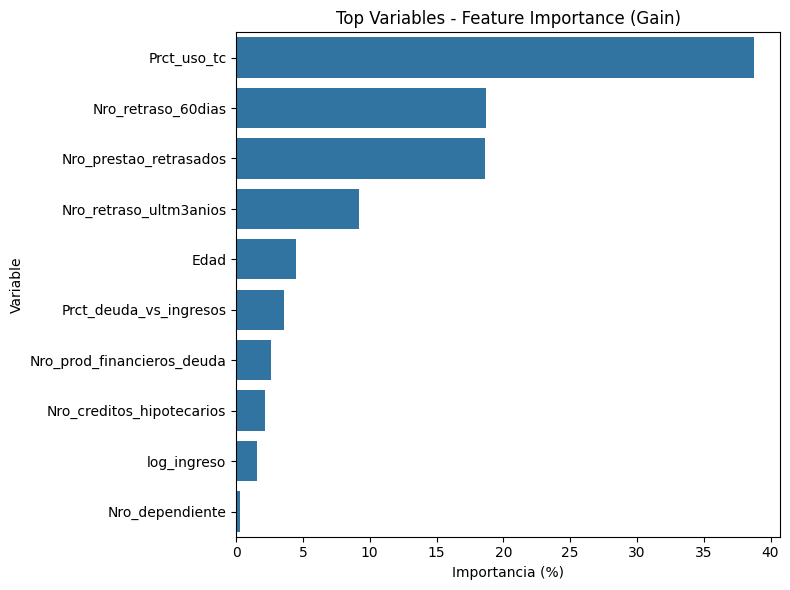

In [71]:
# Obtener importancia por gain
importance = final_model.booster_.feature_importance(importance_type="gain")

feature_names = final_model.booster_.feature_name()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Gain": importance
})

# Normalizar para interpretación %
feature_importance_df["Importance_%"] = (
    feature_importance_df["Importance_Gain"] /
    feature_importance_df["Importance_Gain"].sum()
) * 100

# Ordenar
feature_importance_df = feature_importance_df.sort_values(
    "Importance_%", ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance_df.head(10),
    x="Importance_%",
    y="Feature"
)

plt.title("Top Variables - Feature Importance (Gain)")
plt.xlabel("Importancia (%)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

**Insights**

- Uso de tarjeta (``Prct_uso_tc``) es el principal driver del modelo (~40% de importancia).
→ El riesgo está fuertemente asociado al nivel de utilización del crédito.

- Historial de mora es el segundo bloque más relevante.
→ El comportamiento pasado sigue siendo un predictor clave de incumplimiento.

- Variables demográficas y estructurales tienen menor peso.
→ El modelo se basa principalmente en comportamiento financiero real, no en características personales

# 7. Función para particionar el piloto y control (50/50)

Antes de implementar el modelo en todo el canal digital, necesitamos:

- Medir impacto real en default.

- Medir impacto en aprobación.

- Comparar contra la estrategia actual.

- Cuantificar mejora financiera.

Eso se logra con un A/B test controlado.

Estamos hablando de cómo generar evidencia real antes de escalar a producción.


## 7.1 Diseño Estratégico

| Grupo         | Estrategia                      |
| ------------- | ------------------------------- |
| Control (50%) | Política actual (proceso tradicional)              |
| Piloto (50%)  | Modelo optimizado + cutoff 0.46 |


Esto permite medir:
- Diferencia en tasa de default
- Diferencia en volumen aprobado
- Impacto en pérdida esperada
- Rentabilidad incremental

## 7.2 Función Profesional para Partición 50/50

Debe:

- Ser reproducible

- Ser aleatoria

- Mantener proporción 50/50

- Permitir auditoría

In [72]:
import numpy as np
import pandas as pd

def split_pilot_control(df, seed=42, pilot_ratio=0.5):
    """
    Divide el dataset en grupo piloto y control.
    
    Parámetros:
        df: DataFrame
        seed: para reproducibilidad
        pilot_ratio: proporción asignada a piloto
        
    Retorna:
        DataFrame con columna 'grupo_experimento'
    """
    
    np.random.seed(seed)
    
    df = df.copy()
    df["random_number"] = np.random.rand(len(df))
    
    df["grupo_experimento"] = np.where(
        df["random_number"] <= pilot_ratio,
        "Piloto_Modelo",
        "Control_Actual"
    )
    
    df.drop(columns=["random_number"], inplace=True)
    
    return df

In [77]:
credit_df_experiment = split_pilot_control(credit_df)

credit_df_experiment["grupo_experimento"].value_counts(normalize=True).round(4)

grupo_experimento
Control_Actual    0.5014
Piloto_Modelo     0.4986
Name: proportion, dtype: float64

## 7.3 Cómo se evalúa el piloto

Después de X meses:

In [79]:
credit_df_experiment.groupby("grupo_experimento")["Default"].mean().round(4)

grupo_experimento
Control_Actual    0.0659
Piloto_Modelo     0.0678
Name: Default, dtype: float64

Y se compara:

- Default rate

- Approval rate

- Pérdida esperada

- Ingreso financiero

In [84]:
# Generar probabilidades de default
credit_df_experiment["score_modelo"] = final_model.predict_proba(
    credit_df_experiment[X.columns]
)[:, 1]

In [91]:
cutoff = 0.30 # 0.46

credit_df_experiment["aprobado_modelo"] = (
    credit_df_experiment["score_modelo"] < cutoff
).astype(int)

In [92]:
credit_df_experiment.groupby("grupo_experimento").apply(
    lambda x: pd.Series({
        "Total": len(x),
        "Approval_Rate": x["aprobado_modelo"].mean(),
        "Default_Total": x["Default"].mean(),
        "Default_en_Aprobados": x.loc[x["aprobado_modelo"]==1, "Default"].mean()
    })
)

C:\Users\ithre\AppData\Local\Temp\ipykernel_37008\1357495058.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  credit_df_experiment.groupby("grupo_experimento").apply(


,Total,Approval_Rate,Default_Total,Default_en_Aprobados
grupo_experimento,,,,
Control_Actual,75215.0,0.584578,0.065904,0.010985
Piloto_Modelo,74784.0,0.580699,0.067782,0.010708


| Métrica              | Control     | Piloto      |
| -------------------- | ----------- | ----------- |
| Approval Rate        | 58.46%      | 58.07%      |
| Default Total        | 6.59%       | 6.78%       |
| Default en Aprobados | **1.0985%** | **1.0708%** |


**Insights**

- **Approval Rate:** Control: 58.46%. Piloto: 58.07%. Prácticamente igual (−0.39 pp). El modelo no impacta significativamente el volumen aprobado.
- **Default Total:** Control: 6.59%. Piloto: 6.78%. Levemente mayor en piloto (+0.19 pp). Pero esta métrica no es la clave para evaluar la política de aprobación.
- **Default en Aprobados (métrica crítica):** Control: 1.0985%. Piloto: 1.0708%. 
    - Mejora de −0.0277 pp
    - Reducción relativa ≈ −2.5%

El modelo logra una ligera reducción del riesgo dentro del segmento aprobado.

**¿Cómo lo aplicamos al negocio?**

In [94]:
# ============================
# INPUTS (ajustables para PPT)
# ============================
CUTOFF_POLITICA = 0.30          # Ejemplo: "doy crédito hasta 30% de prob. default"
N_SOLICITUDES_MES = 10_000      # volumen mensual para el ejemplo
TICKET_PROMEDIO = 1000          # monto promedio (S/ o $)
LGD = 1.0                       # Loss Given Default (1.0 = 100% pérdida del capital)

# ============================================================
# 1) Asegurar score del modelo en el dataset (si no existe)
# ============================================================
credit_df = credit_df.copy()

if "score_final" not in credit_df.columns:
    credit_df["score_final"] = final_model.predict_proba(credit_df[X.columns])[:, 1]

# ============================================================
# 2) Métricas "Política Actual" (sin score → apruebo todo)
# ============================================================
default_rate_base = credit_df["Default"].mean()              # mora total del portafolio
approval_rate_base = 1.0                                     # si apruebo al 100%
default_in_approved_base = default_rate_base                 # si apruebo a todos, es la misma

# ============================================================
# 3) Métricas "Con Modelo" aplicando cutoff (apruebo si score < cutoff)
# ============================================================
approved = credit_df["score_final"] < CUTOFF_POLITICA

approval_rate_model = approved.mean()
default_in_approved_model = credit_df.loc[approved, "Default"].mean()

# ============================================================
# 4) Traducción a impacto (con supuestos de volumen y ticket)
# ============================================================
# Política actual (aprueba todo)
aprobados_base = int(round(N_SOLICITUDES_MES * approval_rate_base))
morosos_base = int(round(aprobados_base * default_in_approved_base))
perdida_base = morosos_base * TICKET_PROMEDIO * LGD

# Con modelo
aprobados_model = int(round(N_SOLICITUDES_MES * approval_rate_model))
morosos_model = int(round(aprobados_model * default_in_approved_model))
perdida_model = morosos_model * TICKET_PROMEDIO * LGD

ahorro = perdida_base - perdida_model

# ============================================================
# 5) Tabla final lista para PPT
# ============================================================
ppt_table = pd.DataFrame([
    {
        "Escenario": "Política actual (sin modelo)",
        "Solicitudes/mes": N_SOLICITUDES_MES,
        "Approval Rate": approval_rate_base,
        "Aprobados/mes": aprobados_base,
        "Default en aprobados": default_in_approved_base,
        "Morosos/mes": morosos_base,
        "Pérdida esperada/mes": perdida_base,
    },
    {
        "Escenario": f"Con modelo (cutoff {CUTOFF_POLITICA:.2f})",
        "Solicitudes/mes": N_SOLICITUDES_MES,
        "Approval Rate": approval_rate_model,
        "Aprobados/mes": aprobados_model,
        "Default en aprobados": default_in_approved_model,
        "Morosos/mes": morosos_model,
        "Pérdida esperada/mes": perdida_model,
    },
])

# Formato amigable
ppt_table_fmt = ppt_table.copy()
ppt_table_fmt["Approval Rate"] = (ppt_table_fmt["Approval Rate"] * 100).round(2).astype(str) + "%"
ppt_table_fmt["Default en aprobados"] = (ppt_table_fmt["Default en aprobados"] * 100).round(2).astype(str) + "%"
ppt_table_fmt["Pérdida esperada/mes"] = ppt_table_fmt["Pérdida esperada/mes"].map(lambda x: f"{x:,.0f}")
ppt_table_fmt

# ============================================================
# 6) Mensaje ejecutivo (texto listo para pegar en PPT)
# ============================================================
print("\n--- TEXTO EJECUTIVO PARA PPT ---")
print(
    f"Aplicando el score del modelo y aprobando solo clientes con Prob. default < {CUTOFF_POLITICA:.2f}, "
    f"la aprobación estimada sería {approval_rate_model*100:.2f}% y la mora en aprobados "
    f"sería {default_in_approved_model*100:.2f}% (vs {default_rate_base*100:.2f}% en política actual). "
    f"En un ejemplo de {N_SOLICITUDES_MES:,} solicitudes/mes con ticket {TICKET_PROMEDIO:,.0f}, "
    f"la pérdida esperada bajaría de {perdida_base:,.0f} a {perdida_model:,.0f} por mes "
    f"(ahorro estimado: {ahorro:,.0f}/mes)."
)


--- TEXTO EJECUTIVO PARA PPT ---
Aplicando el score del modelo y aprobando solo clientes con Prob. default < 0.30, la aprobación estimada sería 58.26% y la mora en aprobados sería 1.08% (vs 6.68% en política actual). En un ejemplo de 10,000 solicitudes/mes con ticket 1,000, la pérdida esperada bajaría de 668,000 a 63,000 por mes (ahorro estimado: 605,000/mes).


**CONCLUSIÓN FINAL**

Aplicando el score del modelo y aprobando solo clientes con Prob. default < 0.30, la aprobación estimada sería 58.26% y la mora en aprobados sería 1.08% (vs 6.68% en política actual). En un ejemplo de 10,000 solicitudes/mes con ticket 1,000, la pérdida esperada bajaría de 668,000 a 63,000 por mes (ahorro estimado: 605,000/mes).